# One Portfolio, Three VaRs, One Backtest

Compute 1-day 99% VaR for one real-data portfolio using:
- Historical simulation
- Parametric (delta-normal)
- Monte Carlo simulation

Then backtest all three methods on a rolling window.

The example portfolio is a 60/40 allocation: 60% in `SPY` (US equities) and 40% in `IEF` (intermediate-term US Treasuries), with daily data starting in 2017.

In [ ]:
# If needed, uncomment:
# !pip install yfinance pandas numpy matplotlib scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import yfinance as yf

plt.rcParams["figure.figsize"] = (10, 5)
pd.options.display.float_format = "{:,.4f}".format

In [ ]:
# Parameters
TICKERS = ["SPY", "IEF"]
WEIGHTS = np.array([0.60, 0.40])
PORTFOLIO_NAME = "60/40 SPY-IEF"
V0 = 10_000_000
ALPHA = 0.99
WINDOW = 500
BACKTEST_DAYS = 250
MC_SIMS = 10_000
SEED = 42
START = "2017-01-01"
END = None

## 1. Download prices and build portfolio returns

For asset returns $r_t$ and portfolio weights $w$,

$$
r_{p,t} = w^\top r_t
$$

For a portfolio value $V_0$, the 1-day loss is

$$
L_t = -V_0\, r_{p,t}
$$

We first download adjusted prices for `SPY` and `IEF`, compute daily returns, and then combine them into the 60/40 portfolio return series.

In [ ]:
prices = yf.download(
    TICKERS,
    start=START,
    end=END,
    auto_adjust=True,
    progress=False
)["Close"].dropna()

returns = prices.pct_change().dropna()
portfolio_returns = returns @ WEIGHTS
portfolio_returns.name = "portfolio_return"

display(prices.tail())
display(returns.tail())
portfolio_returns.tail()

Ticker,IEF,SPY
Date,,
2026-04-17,95.9300,710.1400
2026-04-20,95.8400,708.7200
2026-04-21,95.4200,704.0800
2026-04-22,95.5200,711.2100
2026-04-23,95.2850,707.0300


Ticker,IEF,SPY
Date,,
2026-04-17,0.0055,0.0121
2026-04-20,-0.0009,-0.0020
2026-04-21,-0.0044,-0.0065
2026-04-22,0.0010,0.0101
2026-04-23,-0.0025,-0.0059


,portfolio_return
Date,
2026-04-17,0.0081
2026-04-20,-0.0014
2026-04-21,-0.0052
2026-04-22,0.0047
2026-04-23,-0.0038


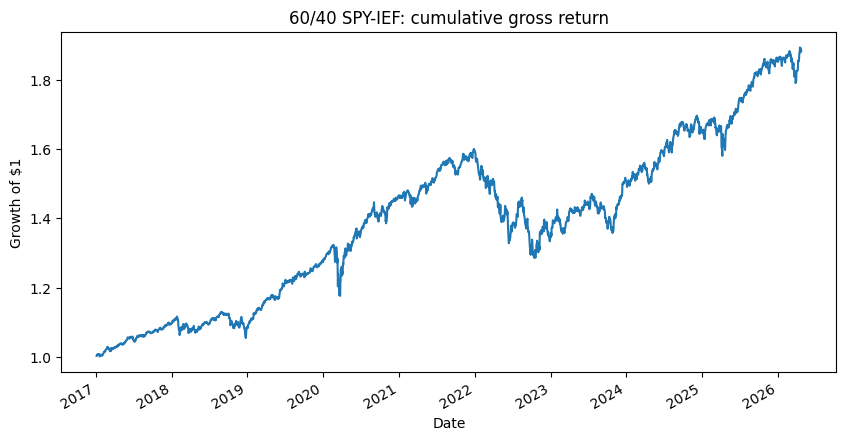

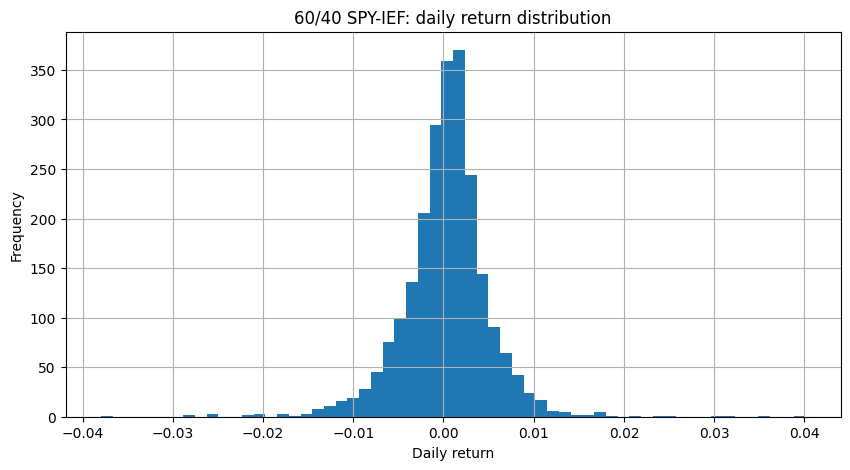

In [ ]:
(1 + portfolio_returns).cumprod().plot(title=f"{PORTFOLIO_NAME}: cumulative gross return")
plt.ylabel("Growth of $1")
plt.show()

portfolio_returns.hist(bins=60)
plt.title(f"{PORTFOLIO_NAME}: daily return distribution")
plt.xlabel("Daily return")
plt.ylabel("Frequency")
plt.show()

## 2. Static VaR estimates from the latest window

Let $L$ denote the 1-day loss distribution.

Historical VaR uses the empirical loss quantile:

$$
\mathrm{VaR}^{\mathrm{hist}}_\alpha = Q_\alpha(L)
$$

Parametric VaR under a normal return model is

$$
\mathrm{VaR}^{\mathrm{par}}_\alpha = V_0\, z_\alpha \sigma_p
$$

where $z_\alpha$ is the standard normal quantile and $\sigma_p$ is portfolio volatility.

Monte Carlo VaR simulates asset returns from a fitted multivariate normal model, forms simulated portfolio losses, and then takes the same loss quantile:

$$
\mathrm{VaR}^{\mathrm{MC}}_\alpha = Q_\alpha(L^{\mathrm{sim}})
$$

We estimate all three using the latest rolling window, which here means the most recent 500 trading days.

In [ ]:
window_returns_assets = returns.iloc[-WINDOW:]
window_returns_portfolio = portfolio_returns.iloc[-WINDOW:]
window_losses = -V0 * window_returns_portfolio

def historical_var(portfolio_returns, alpha=0.99, v0=1.0):
    losses = -v0 * portfolio_returns
    return np.quantile(losses, alpha)

def parametric_var(portfolio_returns, alpha=0.99, v0=1.0):
    sigma = portfolio_returns.std(ddof=1)
    z = norm.ppf(alpha)
    return v0 * sigma * z

def monte_carlo_var(asset_returns, weights, alpha=0.99, v0=1.0, n_sims=10_000, seed=42):
    mu = asset_returns.mean().values
    cov = asset_returns.cov().values
    rng = np.random.default_rng(seed)
    sims = rng.multivariate_normal(mu, cov, size=n_sims)
    portfolio_sims = sims @ weights
    losses = -v0 * portfolio_sims
    return np.quantile(losses, alpha), losses

var_hist = historical_var(window_returns_portfolio, alpha=ALPHA, v0=V0)
var_param = parametric_var(window_returns_portfolio, alpha=ALPHA, v0=V0)
var_mc, mc_losses = monte_carlo_var(
    window_returns_assets, WEIGHTS, alpha=ALPHA, v0=V0, n_sims=MC_SIMS, seed=SEED
)

summary = pd.DataFrame(
    {
        "VaR (€/$)": [var_hist, var_param, var_mc],
        "VaR (% of portfolio)": [var_hist / V0, var_param / V0, var_mc / V0],
    },
    index=["Historical", "Parametric", "Monte Carlo"],
)
summary

,VaR (€/$),VaR (% of portfolio)
Historical,"119,959.8019",0.0120
Parametric,"110,510.8868",0.0111
Monte Carlo,"106,220.3435",0.0106


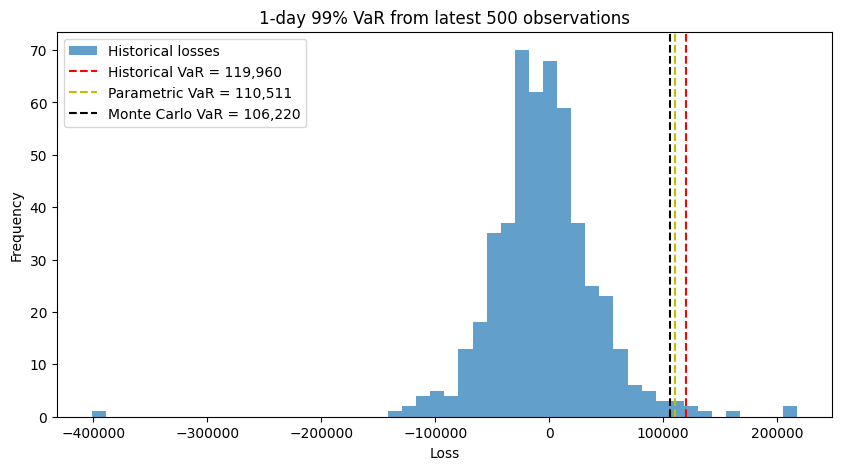

In [ ]:
plt.hist(window_losses, bins=50, alpha=0.7, label="Historical losses")
plt.axvline(var_hist, linestyle="--", color='r',label=f"Historical VaR = {var_hist:,.0f}")
plt.axvline(var_param, linestyle="--", color='y',label=f"Parametric VaR = {var_param:,.0f}")
plt.axvline(var_mc, linestyle="--",color='black', label=f"Monte Carlo VaR = {var_mc:,.0f}")
plt.title(f"1-day {ALPHA:.0%} VaR from latest {WINDOW} observations")
plt.xlabel("Loss")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## 3. Rolling backtest

For each day $t$, use the previous `WINDOW` observations to estimate the next-day VaR forecast $\widehat{\mathrm{VaR}}_{\alpha,t}$.

The realized loss is

$$
L_{t+1} = -V_0\, r_{p,t+1}
$$

An exception occurs when the realized loss exceeds the forecast:

$$
I_{t+1} = \mathbf{1}\!\left\{L_{t+1} > \widehat{\mathrm{VaR}}_{\alpha,t}\right\}
$$

Over $N$ backtest days, a 99% VaR model should produce about $N(1-\alpha)$ exceptions on average. In this notebook, the backtest is run over the last 250 trading days, and we classify the result with the Basel traffic-light rule.

In [ ]:
def rolling_var_backtest(asset_returns, portfolio_returns, weights, v0, alpha, window, backtest_days, n_sims, seed):
    rows = []
    start_idx = len(portfolio_returns) - backtest_days

    for t in range(start_idx, len(portfolio_returns)):
        hist_window_port = portfolio_returns.iloc[t - window:t]
        hist_window_assets = asset_returns.iloc[t - window:t]

        realized_return = portfolio_returns.iloc[t]
        realized_loss = -v0 * realized_return

        hist_var = historical_var(hist_window_port, alpha=alpha, v0=v0)
        param_var = parametric_var(hist_window_port, alpha=alpha, v0=v0)
        mc_var, _ = monte_carlo_var(
            hist_window_assets,
            weights,
            alpha=alpha,
            v0=v0,
            n_sims=n_sims,
            seed=seed + t,
        )

        rows.append(
            {
                "date": portfolio_returns.index[t],
                "realized_loss": realized_loss,
                "Historical": hist_var,
                "Parametric": param_var,
                "Monte Carlo": mc_var,
            }
        )

    out = pd.DataFrame(rows).set_index("date")
    for col in ["Historical", "Parametric", "Monte Carlo"]:
        out[f"{col}_exception"] = out["realized_loss"] > out[col]
    return out

bt = rolling_var_backtest(
    returns,
    portfolio_returns,
    WEIGHTS,
    V0,
    ALPHA,
    WINDOW,
    BACKTEST_DAYS,
    MC_SIMS,
    SEED,
)

bt.head()

,realized_loss,Historical,Parametric,Monte Carlo,Historical_exception,Parametric_exception,Monte Carlo_exception
date,,,,,,,
2025-04-25,"-51,674.3601","121,132.3787","119,573.1932","116,130.8430",False,False,False
2025-04-28,"-25,471.5268","121,132.3787","119,616.7431","117,260.9488",False,False,False
2025-04-29,"-45,911.2752","121,132.3787","119,378.0719","115,571.0225",False,False,False
2025-04-30,"-10,970.3398","121,132.3787","119,185.7559","115,936.1354",False,False,False
2025-05-01,"-2,218.4029","121,132.3787","119,147.8130","113,813.1705",False,False,False


A 99% VaR model over $N$ days has an expected exception count of

$$
N(1-\alpha)
$$

For $N=250$, the Basel traffic-light rule labels the backtest:
- Green: 0 to 4 exceptions
- Yellow: 5 to 9 exceptions
- Red: 10 or more exceptions

In [ ]:
exceptions = pd.DataFrame(
    {
        "Exceptions": [
            bt["Historical_exception"].sum(),
            bt["Parametric_exception"].sum(),
            bt["Monte Carlo_exception"].sum(),
        ]
    },
    index=["Historical", "Parametric", "Monte Carlo"],
)

def basel_zone(n):
    if n <= 4:
        return "Green"
    if n <= 9:
        return "Yellow"
    return "Red"

exceptions["Expected under 99% VaR"] = BACKTEST_DAYS * (1 - ALPHA)
exceptions["Basel zone"] = exceptions["Exceptions"].map(basel_zone)
exceptions

,Exceptions,Expected under 99% VaR,Basel zone
Historical,1,2.5000,Green
Parametric,2,2.5000,Green
Monte Carlo,2,2.5000,Green


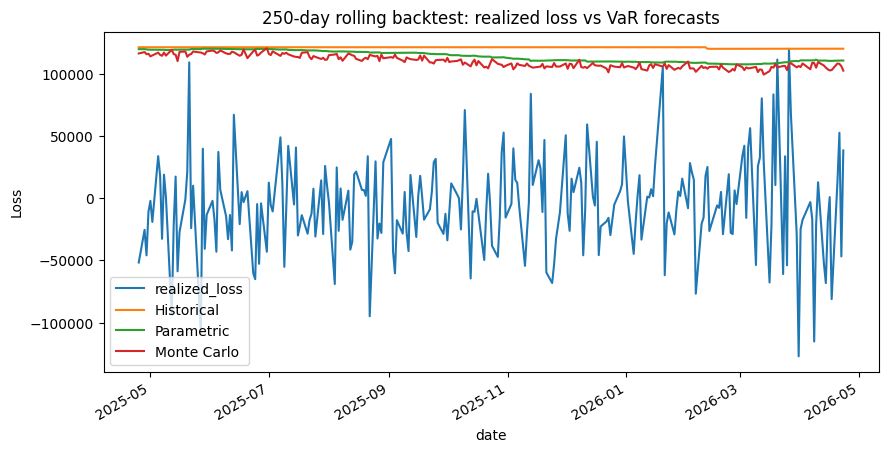

In [ ]:
bt[["realized_loss", "Historical", "Parametric", "Monte Carlo"]].plot(
    title=f"{BACKTEST_DAYS}-day rolling backtest: realized loss vs VaR forecasts"
)
plt.ylabel("Loss")
plt.show()

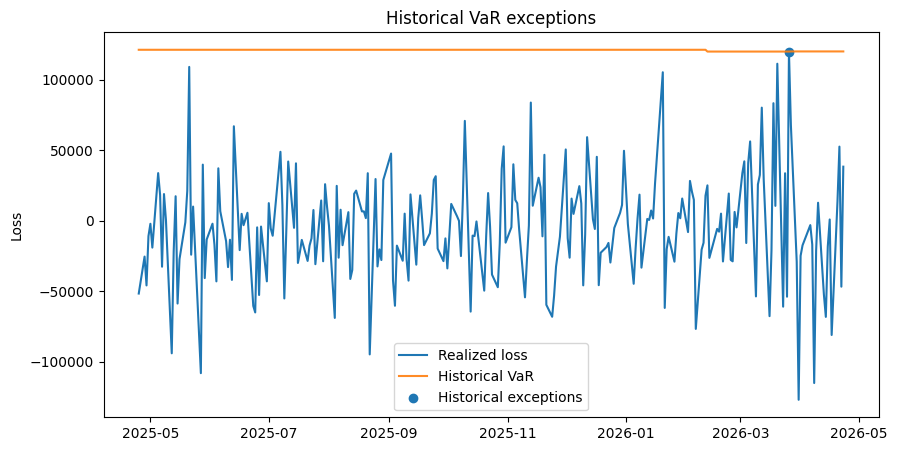

In [ ]:
fig, ax = plt.subplots()

ax.plot(bt.index, bt["realized_loss"], label="Realized loss")
ax.plot(bt.index, bt["Historical"], label="Historical VaR", alpha=0.9)

exception_dates = bt.index[bt["Historical_exception"]]
exception_losses = bt.loc[exception_dates, "realized_loss"]
ax.scatter(exception_dates, exception_losses, label="Historical exceptions")

ax.set_title("Historical VaR exceptions")
ax.set_ylabel("Loss")
ax.legend()
plt.show()

## 4. Short discussion

- Which VaR is largest?
- Which method has the fewest exceptions?
- Do exceptions cluster in volatile periods?
- Does the method you prefer for explanation match the method you prefer for forecasting?

## 5. Easy extensions

- Change the portfolio weights.
- Replace `IEF` with another ETF.
- Repeat the exercise at 95% confidence.
- Add Expected Shortfall.
- Compare a calm sample with a stressed sample.